### Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/sklearn-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Data and Preprocessing

In [5]:
# Load the uploaded label file
df = pd.read_csv("train_rows.csv")

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SpMax_L      837 non-null    float64
 1   J_Dz(e)      837 non-null    float64
 2   nHM          837 non-null    int64  
 3   F01[N-N]     837 non-null    int64  
 4   F04[C-N]     837 non-null    int64  
 5   NssssC       837 non-null    int64  
 6   nCb-         837 non-null    int64  
 7   C%           837 non-null    float64
 8   nCp          837 non-null    int64  
 9   nO           837 non-null    int64  
 10  F03[C-N]     837 non-null    int64  
 11  SdssC        837 non-null    float64
 12  HyWi_B(m)    837 non-null    float64
 13  LOC          837 non-null    float64
 14  SM6_L        837 non-null    float64
 15  F03[C-O]     837 non-null    int64  
 16  Me           837 non-null    float64
 17  Mi           837 non-null    float64
 18  nN-N         837 non-null    int64  
 19  nArNO2       837 no

In [3]:
df.head()

,SpMax_L,J_Dz(e),nHM,F01[N-N],F04[C-N],NssssC,nCb-,C%,nCp,nO,...,C-026,F02[C-N],nHDon,SpMax_B(m),Psi_i_A,nN,SM6_B(m),nArCOOR,nX,Class
0,3.919,2.6909,0,0,0,0,0,31.4,2,0,...,0,0,0,2.949,1.591,0,7.253,0,0,1
1,4.170,2.1144,0,0,0,0,0,30.8,1,1,...,0,0,0,3.315,1.967,0,7.257,0,0,1
2,3.932,3.2512,0,0,0,0,0,26.7,2,4,...,0,0,1,3.076,2.417,0,7.601,0,0,1
3,3.000,2.7098,0,0,0,0,0,20.0,0,2,...,0,0,1,3.046,5.000,0,6.690,0,0,1
4,4.236,3.3944,0,0,0,0,0,29.4,2,4,...,0,0,0,3.351,2.405,0,8.003,0,0,1


In [6]:
categorical_features = [
    col for col in df.select_dtypes(include=["int64"]).columns
    if col != "Class"
]

if categorical_features:
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, drop='first')

    # Fit and transform categorical features
    encoded_array = encoder.fit_transform(df[categorical_features])

    # Get feature names
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)

    # Create DataFrame for encoded features
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

    # Drop original categorical columns and add encoded ones
    df_encoded = df.drop(columns=categorical_features)
    df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
else:
    df_encoded = df.copy()
    encoded_feature_names = []

print(f"\nOriginal shape: {df.shape}")
print(f"After One Hot Encoding shape: {df_encoded.shape}")

# prob_sp used as a target, so it must be dropped
X = df_encoded.drop(columns=["Class"])
y = df_encoded["Class"]

# Normalize all features

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
# Combine back with target
df_final = X_scaled.copy()
df_final["Class"] = y.values
df_final


Original shape: (837, 42)
After One Hot Encoding shape: (837, 215)


,SpMax_L,J_Dz(e),C%,SdssC,HyWi_B(m),LOC,SM6_L,Me,Mi,SpPosA_B(p),...,nX_4,nX_5,nX_6,nX_7,nX_8,nX_10,nX_12,nX_23,nX_27,Class
0,0.443187,0.265233,0.523333,0.520950,0.375752,0.567802,0.572377,0.008955,0.365854,0.448276,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.501155,0.184201,0.513333,0.520950,0.220592,0.310176,0.539301,0.095522,0.371951,0.319629,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.446189,0.343988,0.445000,0.520950,0.417368,0.575596,0.585181,0.155224,0.396341,0.303714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.230947,0.267890,0.333333,0.520950,0.133750,0.204409,0.286900,0.450746,0.442073,0.213528,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.516397,0.364116,0.490000,0.493456,0.458263,0.613004,0.634736,0.140299,0.381098,0.363395,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832,0.230947,0.131422,0.416667,0.520950,0.452730,0.204409,0.286900,0.083582,0.347561,0.689655,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
833,0.704619,0.383456,0.500000,0.440398,0.642290,0.789579,0.775697,0.101493,0.378049,0.368700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
834,0.664203,0.287272,0.500000,0.459268,0.400770,0.265642,0.696977,0.188060,0.402439,0.412467,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
835,0.681986,0.366097,0.666667,0.520950,0.434688,0.283456,0.687730,0.173134,0.326220,0.501326,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [9]:
X = df_final.drop('Class', axis=1)
y = df_final['Class']

print("=" * 60)
print("Data before Oversampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Oversampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# SMOTE Oversampling
print("Applying SMOTE Oversampling")

# Apply SMOTE
smote = SMOTE(random_state=209, sampling_strategy='auto')
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE - X shape: {X.shape}, y shape: {y.shape}")
print(f"After SMOTE  - X shape: {X_resampled.shape}, y shape: {y_resampled.shape}")

# Check new class distribution
print(f"\nClass distribution AFTER SMOTE:")
resampled_dist = Counter(y_resampled)
for cls, count in sorted(resampled_dist.items()):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier PCA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='Class')

Data before Oversampling
Shape X: (837, 41)
Shape y: (837,)

Class distribution before Oversampling:
Class
0    553
1    284
Name: count, dtype: int64
  Class 0: 553 samples (66.07%)
  Class 1: 284 samples (33.93%)
Class Weights
  Class 0: 0.7568
  Class 1: 1.4736
Applying SMOTE Oversampling
Before SMOTE - X shape: (837, 41), y shape: (837,)
After SMOTE  - X shape: (1106, 41), y shape: (1106,)

Class distribution AFTER SMOTE:
  Class 0: 553 samples (50.00%)
  Class 1: 553 samples (50.00%)


### Feature Analysis

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=209,
    class_weight="balanced"
)
# Split 7-1-2
X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=209, stratify=y_resampled
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)

rf.fit(X_train, y_train)
importance = rf.feature_importances_

In [11]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print("Top RF Feature Importance")
print(rf_importance.head(10))

Top RF Feature Importance
SpMax_B(m)     0.096728
SpPosA_B(p)    0.068420
SpMax_L        0.064841
SM6_B(m)       0.063853
SpMax_A        0.050108
nN             0.037355
SdssC          0.037212
nO             0.032274
Mi             0.030728
SM6_L          0.030272
dtype: float64


In [12]:
result = permutation_importance(rf, X_test, y_test)
importance = result.importances_mean
perm_importance = pd.Series(
    importance,
    index=X_test.columns
).sort_values(ascending=False)

print("\nTop Permutation Importance")
print(perm_importance.head(10))


Top Permutation Importance
NssssC         0.011712
Psi_i_A        0.008108
Me             0.007207
SdO            0.006306
SpPosA_B(p)    0.006306
SdssC          0.006306
F03[C-O]       0.004505
nCp            0.004505
nArCOOR        0.004505
nX             0.001802
dtype: float64


             RF_Importance  Permutation_Importance
NssssC            0.019762                0.010811
SdssC             0.037212                0.009009
Psi_i_A           0.027377                0.008108
SdO               0.028870                0.007207
SpPosA_B(p)       0.068420                0.006306
Me                0.024687                0.006306
F03[C-O]          0.029642                0.004505
nArCOOR           0.009322                0.004505
nCp               0.018697                0.003604
nO                0.032274                0.001802


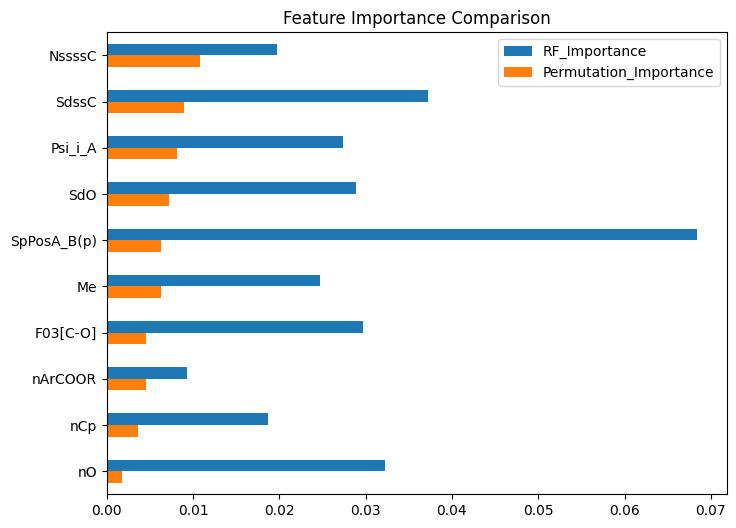

In [16]:
importance_df = pd.DataFrame({
    "RF_Importance": rf_importance,
    "Permutation_Importance": perm_importance
})

importance_df = importance_df.sort_values(
    by="Permutation_Importance",
    ascending=False
)

print(importance_df.head(10))

importance_df.head(10).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Feature Importance Comparison")
plt.show()